# 05 · ML Forecasting — Supervised Reframing, LightGBM, Prophet

## Part 5 — Machine-Learning Forecasting

Classical models (Part 3) *are* the time series — they model autocorrelation directly. The ML
approach is different: **reframe forecasting as ordinary supervised regression** by turning the
series into a table of features, then throw a general learner (gradient-boosted trees) at it.

That unlocks nonlinearity, many exogenous inputs, and one model across many series — but it comes
with two sharp edges this notebook is built around:

1. **Leakage** — a feature for time *t* must use only the past. One careless rolling window and
   your backtest is a fantasy.
2. **Trees cannot extrapolate** — a tree never predicts outside the range of values it saw in
   training, so on a trending series a level-model silently fails. The fix is to model the
   *stationary* part (differences), echoing Part 2.

We use **CO₂** (clear trend + seasonality) so we can score ML head-to-head against the Holt-Winters
/ SARIMA winners from Part 3 on the *same* 24-month holdout.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb
from src import ml_forecast as mlf, forecasting as fc
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.datasets import co2

co2m = co2.load_pandas().data["co2"].resample("MS").mean().interpolate()
H = 24
tr, te = co2m[:-H], co2m[-H:]
LGBM = dict(n_estimators=300, num_leaves=31, learning_rate=0.05, min_child_samples=10,
            random_state=0, verbose=-1)
print("train:", tr.index.min().date(), "->", tr.index.max().date(), "| test:", H, "months")


setup ok | numpy 2.1.3 | pandas 2.3.3


train: 1958-03-01 -> 1999-12-01 | test: 24 months


### 1. Reframe: a series → a supervised table

Slide a window across the series. The features for time *t* are its recent past — **lags**
(`y[t-1]…y[t-12]`), **rolling** mean/std of the past, and **calendar** fields — and the target is
`y[t]`. A 1-D series becomes an (X, y) matrix any regressor can train on.

In [2]:
sup = mlf.make_supervised(tr, n_lags=12)
cols = mlf.feature_cols(sup)
print("supervised table:", sup.shape, "| features:", len(cols))
print(sup[["lag1","lag2","lag12","rmean3","rstd12","month","y"]].head(3).round(2).to_string())

supervised table: (490, 20) | features: 19
              lag1    lag2   lag12  rmean3  rstd12  month       y
1959-03-01  316.70  315.50  316.10  315.63    1.44      3  316.73
1959-04-01  316.73  316.70  317.20  316.31    1.48      4  317.68
1959-05-01  317.68  316.73  317.43  317.04    1.53      5  318.32


### 2. The leakage trap — why every rolling feature is `.shift(1)`

A rolling mean computed as `y.rolling(3).mean()` **includes `y[t]` itself** — the very value you
are trying to predict. Train on that and your model looks brilliant in backtest and collapses
live. The discipline: shift first, then roll, so the window ends at `t-1`.

In [3]:
demo = pd.DataFrame({"y": tr.values}, index=tr.index).head(6)
demo["LEAKY_roll3"]  = demo["y"].rolling(3).mean()          # includes y[t]  <-- contaminated
demo["SAFE_roll3"]   = demo["y"].shift(1).rolling(3).mean() # ends at t-1     <-- correct
print(demo.round(2).to_string())
leaky_corr = tr.rolling(3).mean().corr(tr)
safe_corr  = tr.shift(1).rolling(3).mean().corr(tr)
print(f"\ncorr(feature, target):  LEAKY={leaky_corr:.3f}  vs  SAFE={safe_corr:.3f}")
print("The leaky feature is near-perfectly correlated with the target because it CONTAINS it.")

                 y  LEAKY_roll3  SAFE_roll3
1958-03-01  316.10          NaN         NaN
1958-04-01  317.20          NaN         NaN
1958-05-01  317.43       316.91         NaN
1958-06-01  316.53       317.05      316.91
1958-07-01  315.62       316.53      317.05
1958-08-01  314.95       315.70      316.53

corr(feature, target):  LEAKY=0.998  vs  SAFE=0.992
The leaky feature is near-perfectly correlated with the target because it CONTAINS it.


### 3. Trees can't extrapolate — the level model fails

A decision tree predicts the **average target inside a leaf**, so its output can never exceed the
largest value it saw in training. On a series that only goes *up*, a model trained on **levels**
plateaus just below the last training value while the truth keeps climbing. Watch it undershoot:

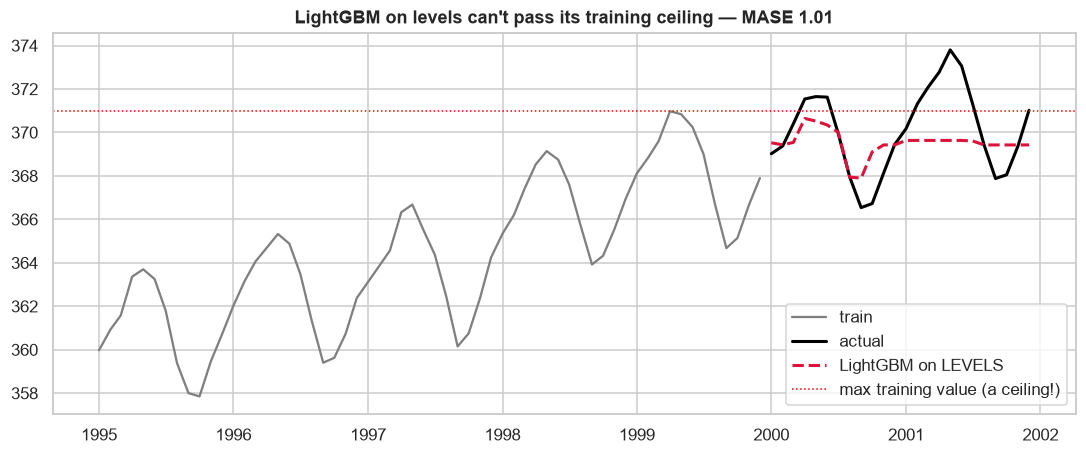

last train=367.9  max prediction=370.6  actual reaches=373.8  -> MASE 1.01 (worse than naive!)


In [4]:
m_lvl = lgb.LGBMRegressor(**LGBM).fit(sup[cols], sup["y"])
pred_lvl = mlf.recursive_forecast(m_lvl, tr, H, cols)
mase_lvl = fc.forecast_metrics(te.values, pred_lvl.values, tr.values, 12)["MASE"]
fig, ax = plt.subplots(figsize=(12,4.5))
ax.plot(tr.index[-60:], tr.values[-60:], color="0.5", label="train")
ax.plot(te.index, te.values, color="black", lw=2, label="actual")
ax.plot(pred_lvl.index, pred_lvl.values, "--", color="crimson", lw=2, label="LightGBM on LEVELS")
ax.axhline(tr.max(), color="red", ls=":", lw=1, label="max training value (a ceiling!)")
ax.set_title(f"LightGBM on levels can't pass its training ceiling — MASE {mase_lvl:.2f}"); ax.legend()
eda.savefig(fig, "p5_level_trap.png"); plt.show()
print("last train=%.1f  max prediction=%.1f  actual reaches=%.1f  -> MASE %.2f (worse than naive!)"
      % (tr.iloc[-1], pred_lvl.max(), te.max(), mase_lvl))

### 4. The fix: model the *difference* (make it stationary first)

Forecast the **change** `Δy = y[t] − y[t-1]` instead of the level. The differenced series has no
trend (Part 2), so its values stay in a fixed range the tree *can* represent — then we rebuild the
level by cumulatively summing the predicted changes onto the last known value.

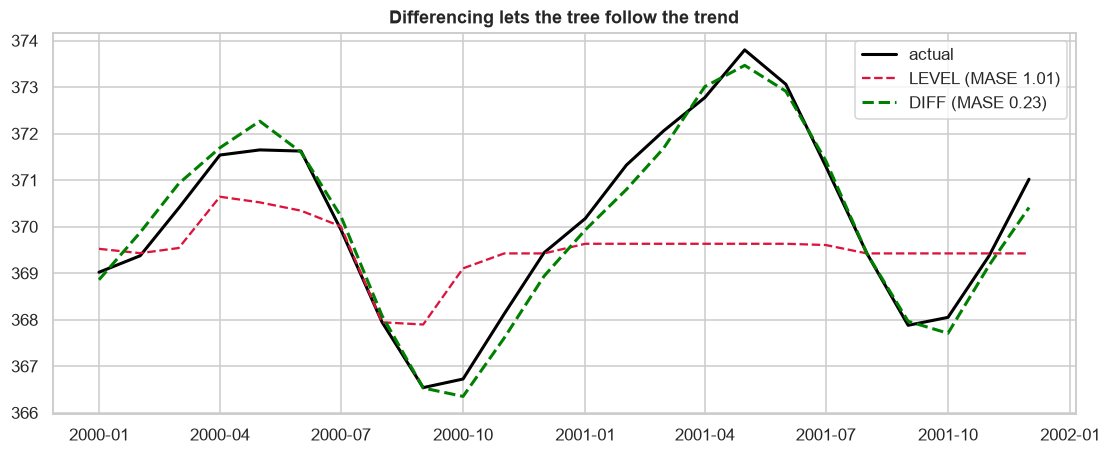

MASE: level=1.011  ->  diff=0.226  (a 4x improvement)


In [5]:
d = tr.diff().dropna()
sup_d = mlf.make_supervised(d, n_lags=12)
m_d = lgb.LGBMRegressor(**LGBM).fit(sup_d[cols], sup_d["y"])
dpred = mlf.recursive_forecast(m_d, d, H, cols)
pred_diff = mlf.reconstruct_from_diff(dpred, tr.iloc[-1])
mase_diff = fc.forecast_metrics(te.values, pred_diff.values, tr.values, 12)["MASE"]
fig, ax = plt.subplots(figsize=(12,4.5))
ax.plot(te.index, te.values, color="black", lw=2, label="actual")
ax.plot(pred_lvl.index, pred_lvl.values, "--", color="crimson", lw=1.5, label=f"LEVEL (MASE {mase_lvl:.2f})")
ax.plot(pred_diff.index, pred_diff.values, "--", color="green", lw=2, label=f"DIFF (MASE {mase_diff:.2f})")
ax.set_title("Differencing lets the tree follow the trend"); ax.legend()
eda.savefig(fig, "p5_diff_fix.png"); plt.show()
print("MASE: level=%.3f  ->  diff=%.3f  (a %.0fx improvement)" % (mase_lvl, mase_diff, mase_lvl/mase_diff))

### 5. Multi-step strategies — recursive vs direct

To forecast H steps with a one-step model you choose a strategy:

- **Recursive** (used above) — predict *t+1*, feed it back in as a lag, predict *t+2*, … One model,
  but **errors compound** down the horizon.
- **Direct** — train a *separate* model for each horizon (one predicts *t+1*, another *t+2*, …). No
  error feedback, but H models and no shared coherence.
- **Hybrid / multi-output** — libraries like `mlforecast`, `sktime`, `skforecast` automate both.

Recursive is the common default; direct shines at long horizons where compounding hurts.

### 6. What did the model learn? — feature importance

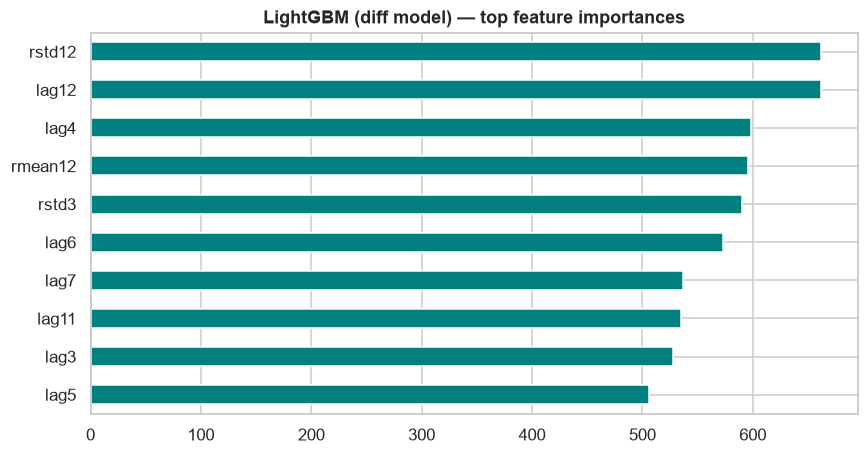

Top features: ['rstd12', 'lag12', 'lag4', 'rmean12', 'rstd3']
Note lag12 & rolling-12 rank high -> the model rediscovered the 12-month SEASONALITY.


In [6]:
imp = pd.Series(m_d.feature_importances_, index=cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9,4.5))
imp.head(10)[::-1].plot.barh(ax=ax, color="teal")
ax.set_title("LightGBM (diff model) — top feature importances")
eda.savefig(fig, "p5_importance.png"); plt.show()
print("Top features:", list(imp.head(5).index))
print("Note lag12 & rolling-12 rank high -> the model rediscovered the 12-month SEASONALITY.")

### 7. Honest scoreboard — ML vs the classical winners

Same series, same holdout, same metric. Does the gradient-boosted tree beat Holt-Winters and
SARIMA from Part 3?

In [7]:
hw  = ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=12).fit().forecast(H).values
sar = SARIMAX(tr, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False).forecast(H).values
board = fc.compare_models(te, {"LGBM-level":pred_lvl.values, "LGBM-diff":pred_diff.values,
                               "Holt-Winters":hw, "SARIMA":sar}, tr, m=12)
print(board.to_string())

                 MAE    RMSE   MAPE%  sMAPE%    MASE
Holt-Winters  0.2357  0.3070  0.0636  0.0636  0.1815
LGBM-diff     0.2931  0.3496  0.0792  0.0792  0.2257
SARIMA        0.3338  0.4095  0.0900  0.0900  0.2570
LGBM-level    1.3128  1.7279  0.3539  0.3546  1.0110


The honest result: on a **clean, low-noise, strongly-seasonal** series, a well-specified
classical model (**Holt-Winters**) still edges out LightGBM. ML is **not automatically better**.
Trees earn their keep when you have **many exogenous drivers, nonlinear interactions, many related
series, or large data** — not on a single tidy seasonal line. Knowing *when not* to reach for ML is
part of the skill.

### 8. Prophet — a decomposition model in disguise

Meta's **Prophet** fits `y(t) = trend + seasonality + holidays + noise` with an interpretable,
auto-tuned curve. It is robust, needs little babysitting, and handles missing data and shifts well
— popular for business series. It is *not* a silver bullet (it can lag turning points), but it is a
strong, low-effort baseline.

10:45:08 - cmdstanpy - INFO - Chain [1] start processing


10:45:08 - cmdstanpy - INFO - Chain [1] done processing


                 MAE    RMSE   MAPE%  sMAPE%    MASE
Prophet       0.2213  0.2666  0.0598  0.0598  0.1705
Holt-Winters  0.2357  0.3070  0.0636  0.0636  0.1815
LGBM-diff     0.2931  0.3496  0.0792  0.0792  0.2257
SARIMA        0.3338  0.4095  0.0900  0.0900  0.2570


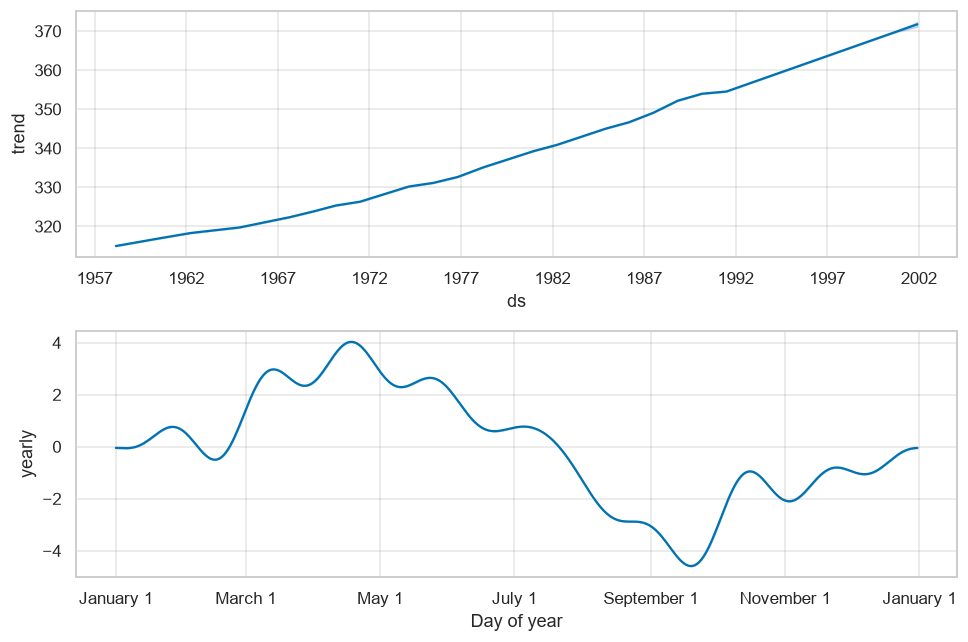

In [8]:
import logging
for lg in ("cmdstanpy", "prophet"): logging.getLogger(lg).setLevel(logging.CRITICAL)
from prophet import Prophet
dfp = tr.reset_index(); dfp.columns = ["ds", "y"]
mp = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
mp.fit(dfp)
fcst = mp.predict(mp.make_future_dataframe(periods=H, freq="MS"))
pred_prophet = fcst.set_index("ds")["yhat"].iloc[-H:].values
board2 = fc.compare_models(te, {"Holt-Winters":hw, "SARIMA":sar, "LGBM-diff":pred_diff.values,
                                "Prophet":pred_prophet}, tr, m=12)
print(board2.to_string())
fig = mp.plot_components(fcst); fig.set_size_inches(9,6); eda.savefig(fig, "p5_prophet_components.png"); plt.show()

### 9. The modern landscape — deep learning & foundation models

Beyond trees, when data is large and patterns complex:

| family | examples | when it wins |
|---|---|---|
| **RNNs** | LSTM, GRU | sequence memory; long-ish dependencies (now often superseded) |
| **Convolutional** | TCN, WaveNet | long receptive field, parallel training |
| **Modern DL** | **N-BEATS, N-HiTS, DeepAR, TFT** | many related series, covariates, probabilistic output |
| **Transformers** | Informer, PatchTST | very long horizons, large datasets |
| **Foundation models** | **TimeGPT, Chronos, TimesFM, Moirai** | *zero-shot* forecasting — pretrained, no training data needed |

Ecosystem: **Nixtla** (`statsforecast`, `mlforecast`, `neuralforecast`), **Darts**, **sktime**,
**GluonTS**. The honest guidance hasn't changed: **start with a baseline + a classical model**
(Parts 3), add **gradient-boosted trees with good features** (this notebook) next, and only reach
for deep/foundation models when you have the scale and the many-series structure to justify them.
Always measure against the naive baseline (Part 6).

### Takeaways

- ML forecasting = **reframe the series as (X, y)** with lag / rolling / calendar features.
- **Leakage is the cardinal sin**: every rolling feature is `.shift(1)` so it ends at `t-1`.
- **Trees can't extrapolate** — a level model undershoots any trend (MASE ≈ 1, worse than naive);
  **model the difference** and reconstruct (MASE ≈ 0.23). Stationarity matters for ML too.
- Multi-step = **recursive** (compounds error) vs **direct** (one model per horizon).
- Feature importance is interpretable — the tree **rediscovered the lag-12 seasonality**.
- **Honest result**: on a clean seasonal series the **decomposition / classical models
  (Prophet ≈ Holt-Winters) beat LightGBM**. ML shines with exogenous drivers, nonlinearity, scale,
  and many related series — not on one tidy line.
- **Prophet** is a strong low-effort decomposition baseline; deep & **foundation models** are the
  frontier for large, many-series problems.

**Next — Part 6 (Evaluation & Backtesting):** the metric zoo (MASE/WAPE vs MAPE), **time-series
cross-validation** (expanding/rolling windows — never shuffle), a **walk-forward backtester**, and
**conformal** prediction intervals — the rigor that tells you which of all these models to trust.